In [1]:
import random
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print('Using device:', device)

Using device: mps


In [2]:
!wget https://mindspore-website.obs.cn-north-4.myhuaweicloud.com/notebook/datasets/MNIST_Data.zip
# !wget -O MNIST.zip https://www.kaggle.com/api/v1/datasets/download/novinnouri/mnist-dataset # kaggle 镜像，先假定这个神奇的华为镜像是好的并且和kaggle上的数据集一致
!unzip -o MNIST_Data.zip

zsh:1: command not found: wget
unzip:  cannot find or open MNIST_Data.zip, MNIST_Data.zip.zip or MNIST_Data.zip.ZIP.


In [3]:
import os
import struct

class RawBinaryMNISTDataset(Dataset):
    def __init__(self, data_dir, training=True):
        if training:
            subdir = 'train'
            img_name = 'train-images-idx3-ubyte'
            lbl_name = 'train-labels-idx1-ubyte'
        else:
            subdir = 'test'
            img_name = 't10k-images-idx3-ubyte'
            lbl_name = 't10k-labels-idx1-ubyte'

        img_path = os.path.join(data_dir, subdir, img_name)
        lbl_path = os.path.join(data_dir, subdir, lbl_name)

        # 解析标签文件 (Header: Magic 4字节, Count 4字节)
        with open(lbl_path, 'rb') as lbpath:
            magic, n = struct.unpack('>II', lbpath.read(8))
            self.labels = np.frombuffer(lbpath.read(), dtype=np.uint8)

        # 解析图像文件 (Header: Magic, Count, Rows, Cols 均为4字节)
        with open(img_path, 'rb') as imgpath:
            magic, num, rows, cols = struct.unpack(">IIII", imgpath.read(16))
            # 将二进制数据读取为 numpy 数组并重塑为 (N, 28, 28)
            self.images = np.frombuffer(imgpath.read(), dtype=np.uint8).reshape(len(self.labels), 28, 28)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # 获取原始像素并转为 float32
        img = self.images[idx]
        label = int(self.labels[idx])

        # 归一化到 [0, 1]
        img_tensor = torch.from_numpy(img).float() / 255.0

        # 增加维度 (1, 28, 28) 并缩放到 (1, 32, 32) 以适配原代码的 LeNet 输入
        img_tensor = img_tensor.unsqueeze(0).unsqueeze(0)
        img_tensor = torch.nn.functional.interpolate(img_tensor, size=(32, 32), mode='bilinear', align_corners=False)
        img_tensor = img_tensor.squeeze(0) # 变为 (1, 32, 32)

        # MNIST 标准化参数
        img_tensor = (img_tensor - 0.1307) / 0.3081

        return img_tensor, label

def create_dataloader(data_dir='MNIST_Data', training=True, batch_size=32):
    ds = RawBinaryMNISTDataset(data_dir=data_dir, training=training)

    loader = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=training,
        drop_last=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    return loader

train_loader = create_dataloader(training=True)
test_loader = create_dataloader(training=False)

/var/folders/2v/7rdtv6_x6jb3zhcgzt0q7ry40000gn/T/ipykernel_49030/1211736682.py:38: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  img_tensor = torch.from_numpy(img).float() / 255.0


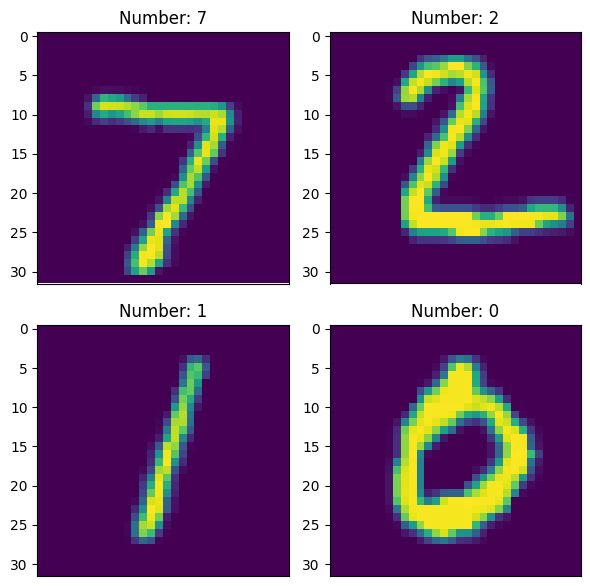

In [4]:
images, labels = next(iter(test_loader))

plt.figure(figsize=(6, 6))
for i in range(4):
    plt.subplot(2, 2, i + 1)
    img = images[i][0].numpy()
    img = img * 0.3081 + 0.1307 # 反归一化
    plt.imshow(img)
    plt.title(f'Number: {labels[i].item()}')
    plt.xticks([]) # 隐藏 x 轴刻度
plt.tight_layout()
plt.show()

In [5]:
class LeNet5(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=0)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=0)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        return x

epoch: 1, train_loss: 0.495127, eval_loss: 0.132399, eval_acc: 0.959435
epoch: 2, train_loss: 0.115902, eval_loss: 0.085962, eval_acc: 0.973858
epoch: 3, train_loss: 0.086669, eval_loss: 0.077810, eval_acc: 0.974760
epoch: 4, train_loss: 0.073273, eval_loss: 0.065189, eval_acc: 0.978165
epoch: 5, train_loss: 0.063529, eval_loss: 0.059846, eval_acc: 0.982372
Metrics: {'loss': 0.059846, 'acc': 0.982372}


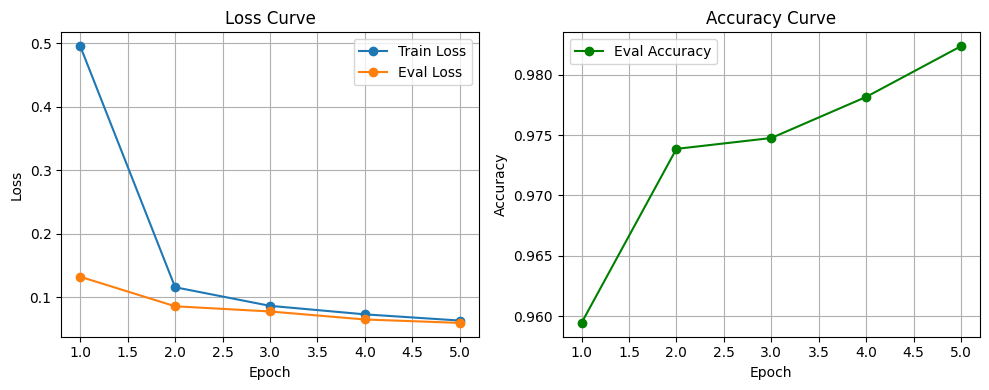

In [14]:
def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total_count += labels.size(0)

    avg_loss = total_loss / total_count
    acc = total_correct / total_count
    return avg_loss, acc


def train(data_dir='MNIST_Data', lr=0.001, momentum=0.9, num_epochs=5, batch_size=32):
    train_loader = create_dataloader(data_dir=data_dir, training=True, batch_size=batch_size)
    test_loader = create_dataloader(data_dir=data_dir, training=False, batch_size=batch_size)

    model = LeNet5().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)

    # 记录日志
    import datetime
    import os
    log_filename = f"train_log_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.txt"
    with open(log_filename, 'w') as f:
        f.write(f"Hyperparameters: lr={lr}, momentum={momentum}, num_epochs={num_epochs}, batch_size={batch_size}\n")

    train_losses = []
    eval_losses = []
    eval_accs = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        total_samples = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            total_samples += images.size(0)

        train_loss = running_loss / total_samples
        eval_loss, eval_acc = evaluate(model, test_loader, criterion, device)
        
        train_losses.append(train_loss)
        eval_losses.append(eval_loss)
        eval_accs.append(eval_acc)
        
        log_str = f'epoch: {epoch + 1}, train_loss: {train_loss:.6f}, eval_loss: {eval_loss:.6f}, eval_acc: {eval_acc:.6f}'
        print(log_str)
        with open(log_filename, 'a') as f:
            f.write(log_str + "\n")

    print('Metrics:', {'loss': round(eval_loss, 6), 'acc': round(eval_acc, 6)})
    
    # 绘制可视化曲线
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss', marker='o')
    plt.plot(range(1, num_epochs + 1), eval_losses, label='Eval Loss', marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss Curve')
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(range(1, num_epochs + 1), eval_accs, label='Eval Accuracy', marker='o', color='green')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy Curve')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

train('MNIST_Data')
